# UNSW-NB15 - Data Cleaning & Feature Engineering

**Project:** IoT Packet Loss Reduction using ML

**Input:** `unsw_combined_dataset.csv` (built by `01_combine_raw_data.ipynb`) - 2,540,047 rows x 49 columns, headers applied to the raw UNSW-NB15 parts. Read-only here, never modified.

**Design rule:** every code cell performs exactly one action, so the pipeline can be re-run end-to-end.

**Key constraint that shapes every decision below (agreed on before writing this notebook):** the trained model must eventually predict packet-loss risk **just before a packet is sent**, inside a router simulation. That means every feature kept here has to be something knowable *before* sending - our own outgoing packet's properties, and rolling counts of *past* traffic. Anything that only exists *after* a packet is sent (destination-side stats, round-trip timings, the final connection outcome) cannot be a model input - it can only help build the *label* we're training against. This is a different (and more important) filter than plain sparsity, so several columns below are kept or dropped for this timing reason even where the sparsity numbers alone might have suggested otherwise.

## Contents

1. Load the combined dataset (read-only)
2. Explore & decide which columns to keep
3. Step 1 - remove columns
4. Step 2 - clean the data (duplicates, placeholders, rare categories)
5. Step 3 - feature engineering (target + 6 new columns)
6. Sanity-check the finished dataset
7. Save the final dataset
8. Recap

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
plt.rcParams['figure.figsize'] = (10, 5)

RAW_PATH = 'unsw_combined_dataset.csv'

print('Environment ready.')

Environment ready.


## Section 1 - Load the combined dataset (read-only)

`df_raw` is only ever read from in this notebook. `unsw_combined_dataset.csv` is never written back to.

In [2]:
df_raw = pd.read_csv(RAW_PATH, low_memory=False)
print('Shape:', df_raw.shape)
df_raw.head()

Shape: (2540047, 49)


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,service,Sload,Dload,Spkts,Dpkts,swin,dwin,stcpb,dtcpb,smeansz,dmeansz,trans_depth,res_bdy_len,Sjit,Djit,Stime,Ltime,Sintpkt,Dintpkt,tcprtt,synack,ackdat,is_sm_ips_ports,ct_state_ttl,ct_flw_http_mthd,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,29,0,0,dns,500473.93750,621800.93750,2,2,0,0,0,0,66,82,0,0,0.00000,0.000000,1421927414,1421927414,0.017,0.013000,0.0,0.0,0.0,0,0,0.0,0.0,0,3,7,1,3,1,1,1,NaN,0
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,29,0,0,-,87676.08594,50480.17188,4,4,0,0,0,0,132,76,0,0,9.89101,10.682733,1421927414,1421927414,7.005,7.564333,0.0,0.0,0.0,0,0,0.0,0.0,0,2,4,2,3,1,1,2,NaN,0
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,29,0,0,dns,521894.53130,636282.37500,2,2,0,0,0,0,73,89,0,0,0.00000,0.000000,1421927414,1421927414,0.017,0.013000,0.0,0.0,0.0,0,0,0.0,0.0,0,12,8,1,2,2,1,1,NaN,0
3,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,29,0,0,dns,436724.56250,542597.18750,2,2,0,0,0,0,66,82,0,0,0.00000,0.000000,1421927414,1421927414,0.043,0.014000,0.0,0.0,0.0,0,0,0.0,0.0,0,6,9,1,1,1,1,1,NaN,0
4,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,29,0,0,dns,499572.25000,609067.56250,2,2,0,0,0,0,73,89,0,0,0.00000,0.000000,1421927414,1421927414,0.005,0.003000,0.0,0.0,0.0,0,0,0.0,0.0,0,7,9,1,1,1,1,1,NaN,0


## Section 2 - Explore & decide which columns to keep

### 2a. Pre-send vs. post-send classification

Every one of the 49 columns falls into one of three buckets:

- **Pre-send** - knowable before the packet goes out (our own packet's proto/service/size, or rolling counts of *past* traffic). Safe as model input.
- **Post-send** - only exists after the packet was sent and (maybe) answered (destination-side stats, round-trip timing, final connection state, loss counts). Useful for building the training *label* and for later before/after comparisons - never a model input.
- **Identity / noise** - random or testbed-specific values (raw IPs, ephemeral source port, TCP sequence numbers, raw absolute timestamps) that can't generalize regardless of timing.

### 2b. Supporting sparsity/cardinality check

On top of the timing classification, we also measure how populated/meaningful each column actually is - a column that's a near-constant or almost always a placeholder can't carry signal either way.

In [3]:
def column_profile(df):
    n = len(df)
    rows = []
    for c in df.columns:
        col = df[c]
        if col.dtype == object:
            placeholder = (col.astype(str).str.strip() == '-').sum()
        else:
            placeholder = (col == 0).sum()
        rows.append({
            'column': c,
            'dtype': str(col.dtype),
            'na_pct': round(col.isna().mean() * 100, 1),
            'placeholder_or_zero_pct': round(placeholder / n * 100, 1),
            'n_unique': col.nunique(dropna=True),
        })
    return pd.DataFrame(rows).set_index('column')

profile = column_profile(df_raw)
profile

,dtype,na_pct,placeholder_or_zero_pct,n_unique
column,,,,
srcip,str,0.0,0.0,43
sport,str,0.0,0.0,64600
dstip,str,0.0,0.0,47
dsport,str,0.0,0.0,64630
proto,str,0.0,0.0,135
state,str,0.0,0.0,16
dur,float64,0.0,0.3,587303
sbytes,int64,0.0,0.0,14155
dbytes,int64,0.0,19.7,19166


### 2c. Column decision - "basic" drops only

This notebook only drops columns that are **objectively unusable, regardless of which model or feature set gets chosen later** - identity columns, corrupted/random values, or fields that are almost never populated. Anything that's valid data but gets excluded from the model for statistical reasons (leakage, dominance, etc.) is a modeling decision, not a data-quality one - that happens in the next notebook (`03`), against `X` only, with the full column still sitting in this file for reference.

**Drop 14 columns:**

| Column | Reason |
|---|---|
| `srcip` | only 43 unique values - a fixed testbed of 43 machines; a model would memorize "this IP = attack" instead of learning a generalizable pattern |
| `dstip` | only 47 unique values - same testbed-memorization problem |
| `sport` | 64,600 unique values (near-random ephemeral port) plus a handful of corrupted hex entries |
| `dsport` | 64,630 unique values plus corrupted hex entries - too messy/random to use raw. Bucketed into `dst_port_bucket` instead before being dropped |
| `Stime`, `Ltime` | raw absolute Unix timestamps - not generalizable as raw numbers |
| `stcpb`, `dtcpb` | ~1.43M unique values each out of 2.54M rows - essentially random per-connection IDs |
| `trans_depth`, `res_bdy_len` | ~92% zero - HTTP-only fields |
| `ct_flw_http_mthd` | ~92% not-applicable (NaN + zero combined) - HTTP-only |
| `is_ftp_login`, `ct_ftp_cmd` | ~98% not-applicable - FTP-only, same rows |
| `is_sm_ips_ports` | 99.8% constant zero - no usable signal |

**Keep the remaining 35 columns**, including `attack_cat`/`Label` (kept as reference metadata, never fed to the model as a feature), the post-send columns (`sloss`, `dloss`, `dbytes`, `state`, `tcprtt`, etc. - these stay for label-building and before/after analysis), and every candidate pre-send feature (`proto`, `service`, `Spkts`, `swin`, etc.) - even the ones that will turn out to be bad model inputs. Notebook 03 decides that, with evidence.

In [4]:
drop_cols = [
    'srcip', 'dstip', 'sport', 'dsport', 'Stime', 'Ltime', 'stcpb', 'dtcpb',
    'trans_depth', 'res_bdy_len', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'is_sm_ips_ports',
]

keep_cols = [c for c in df_raw.columns if c not in drop_cols]

assert len(drop_cols) + len(keep_cols) == df_raw.shape[1]
print(f"Dropping {len(drop_cols)} columns, keeping {len(keep_cols)} columns (out of {df_raw.shape[1]} total)")
keep_cols

Dropping 14 columns, keeping 35 columns (out of 49 total)


['proto',
 'state',
 'dur',
 'sbytes',
 'dbytes',
 'sttl',
 'dttl',
 'sloss',
 'dloss',
 'service',
 'Sload',
 'Dload',
 'Spkts',
 'Dpkts',
 'swin',
 'dwin',
 'smeansz',
 'dmeansz',
 'Sjit',
 'Djit',
 'Sintpkt',
 'Dintpkt',
 'tcprtt',
 'synack',
 'ackdat',
 'ct_state_ttl',
 'ct_srv_src',
 'ct_srv_dst',
 'ct_dst_ltm',
 'ct_src_ltm',
 'ct_src_dport_ltm',
 'ct_dst_sport_ltm',
 'ct_dst_src_ltm',
 'attack_cat',
 'Label']

## Section 3 - Step 1: remove columns

No rows are touched here. `dsport` is set aside separately (`dsport_raw`) so it can still be used to build `dst_port_bucket` in the feature engineering step, even though the raw column itself is being dropped.

In [5]:
dsport_raw = df_raw['dsport']

df_step1 = df_raw[keep_cols].copy()
print('Rows unchanged:', len(df_step1) == len(df_raw))
print('Shape after column removal:', df_step1.shape)
df_step1.head()

Rows unchanged: True
Shape after column removal: (2540047, 35)


,proto,state,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,service,Sload,Dload,Spkts,Dpkts,swin,dwin,smeansz,dmeansz,Sjit,Djit,Sintpkt,Dintpkt,tcprtt,synack,ackdat,ct_state_ttl,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,udp,CON,0.001055,132,164,31,29,0,0,dns,500473.93750,621800.93750,2,2,0,0,66,82,0.00000,0.000000,0.017,0.013000,0.0,0.0,0.0,0,3,7,1,3,1,1,1,NaN,0
1,udp,CON,0.036133,528,304,31,29,0,0,-,87676.08594,50480.17188,4,4,0,0,132,76,9.89101,10.682733,7.005,7.564333,0.0,0.0,0.0,0,2,4,2,3,1,1,2,NaN,0
2,udp,CON,0.001119,146,178,31,29,0,0,dns,521894.53130,636282.37500,2,2,0,0,73,89,0.00000,0.000000,0.017,0.013000,0.0,0.0,0.0,0,12,8,1,2,2,1,1,NaN,0
3,udp,CON,0.001209,132,164,31,29,0,0,dns,436724.56250,542597.18750,2,2,0,0,66,82,0.00000,0.000000,0.043,0.014000,0.0,0.0,0.0,0,6,9,1,1,1,1,1,NaN,0
4,udp,CON,0.001169,146,178,31,29,0,0,dns,499572.25000,609067.56250,2,2,0,0,73,89,0.00000,0.000000,0.005,0.003000,0.0,0.0,0.0,0,7,9,1,1,1,1,1,NaN,0


## Section 4 - Step 2: clean the data

### 4a. Duplicate rows - why the definition matters

Deduping *after* dropping columns can silently wipe out genuinely repeated attack traffic (a scan or a flood *is* a burst of near-identical rows). We compare duplicate counts on the full 49-column record vs. the trimmed 35-column record, broken down by attack category, before deciding.

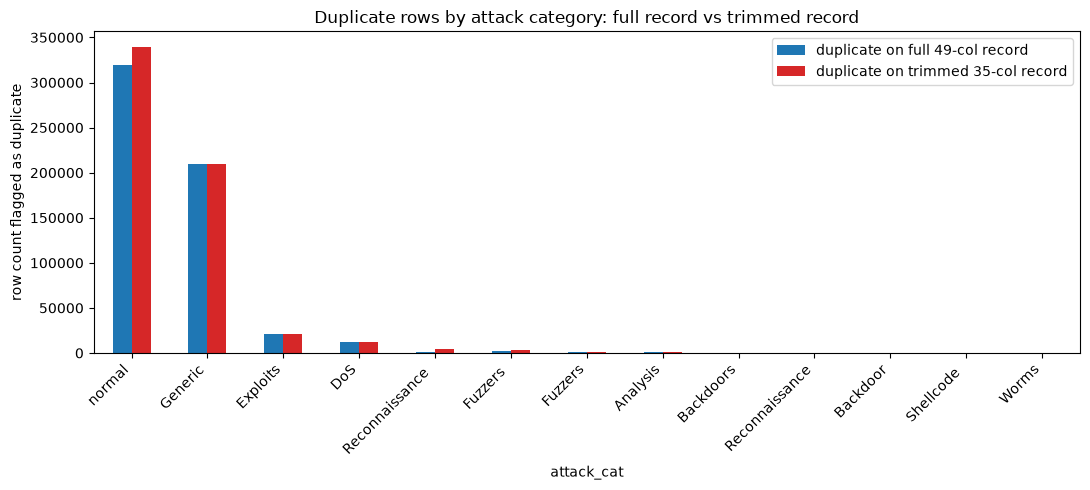

In [6]:
dup_full_mask = df_raw.duplicated(keep=False)
dup_trim_mask = df_step1.duplicated(keep=False)

full_cat = df_raw.loc[dup_full_mask, 'attack_cat'].fillna('normal').value_counts()
trim_cat = df_raw.loc[dup_trim_mask, 'attack_cat'].fillna('normal').value_counts()

comparison = pd.DataFrame({
    'duplicate on full 49-col record': full_cat,
    'duplicate on trimmed 35-col record': trim_cat,
}).fillna(0).sort_values('duplicate on trimmed 35-col record', ascending=False)

comparison.plot(kind='bar', figsize=(11, 5), color=['#1f77b4', '#d62728'])
plt.ylabel('row count flagged as duplicate')
plt.title('Duplicate rows by attack category: full record vs trimmed record')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4b. Apply the safe duplicate definition

**Decision: detect duplicates on the full original 49-column record, then apply that same row selection to the trimmed dataset** - this avoids silently deleting genuinely repeated attack traffic, even though the gap between the two definitions is fairly small on this dataset.

In [7]:
dup_mask = df_raw.duplicated(keep='first')
print(f"True duplicate rows (identical across all {df_raw.shape[1]} original columns): {dup_mask.sum():,}")

True duplicate rows (identical across all 49 original columns): 480,633


In [8]:
df_step2 = df_step1.loc[~dup_mask].reset_index(drop=True)
dsport_raw = dsport_raw.loc[~dup_mask].reset_index(drop=True)

print('Rows before dedup:', len(df_step1))
print('Rows after dedup :', len(df_step2))
print('Rows removed     :', len(df_step1) - len(df_step2))

Rows before dedup: 2540047
Rows after dedup : 2059414
Rows removed     : 480633


### 4c. Placeholder values - `service`

`service == "-"` means Zeek/Argus couldn't identify an application-layer protocol for that connection - a legitimate state for raw TCP/UDP/ICMP traffic, not an error. We recode it to a clear category, `"none"`, so it reads as valid data rather than a missing value.

In [9]:
print('Before recode:')
print(df_step2['service'].value_counts().head())

df_step2['service'] = df_step2['service'].replace('-', 'none')

print()
print('After recode:')
print(df_step2['service'].value_counts().head())

Before recode:
service
-           1169177
dns          386755
http         203531
ftp-data     124849
smtp          81132
Name: count, dtype: int64

After recode:
service
none        1169177
dns          386755
http         203531
ftp-data     124849
smtp          81132
Name: count, dtype: int64


### 4d. Rare protocol categories - `proto`

`proto` has 135 distinct values, but only 6 of them (`tcp`, `udp`, `unas`, `arp`, `ospf`, `sctp`) have at least 1,000 rows - together covering 99.25% of the data. The other 129 protocols total 18,949 rows (0.75%) and are too rare individually to let the model learn anything reliable about them, so they're collapsed into `"other"`.

In [10]:
proto_counts = df_step2['proto'].value_counts()
common_protocols = proto_counts[proto_counts >= 1000].index
print(f"Keeping {len(common_protocols)} protocol categories as-is, collapsing {len(proto_counts) - len(common_protocols)} rare ones into 'other'")

df_step2['proto'] = df_step2['proto'].where(df_step2['proto'].isin(common_protocols), 'other')
df_step2['proto'].value_counts()

Keeping 5 protocol categories as-is, collapsing 130 rare ones into 'other'


proto
tcp      1448858
udp       588026
other       7143
arp         6658
unas        4765
ospf        3964
Name: count, dtype: int64

### 4e. True missing values

After dropping the two FTP-only / HTTP-only columns that carried all the NaNs (`is_ftp_login`, `ct_flw_http_mthd`), the only column with nulls left should be `attack_cat` - which is *expected* to be null for every normal (non-attack) row, since it's reference metadata, not a feature.

In [11]:
na_counts = df_step2.isna().sum()
na_counts = na_counts[na_counts > 0]
print(na_counts)

assert list(na_counts.index) == ['attack_cat'], 'Unexpected NaNs outside attack_cat'
assert na_counts['attack_cat'] == (df_step2['Label'] == 0).sum(), 'attack_cat NaNs should exactly match normal rows'
print('\\nConfirmed: attack_cat is null only for normal (Label=0) rows, as expected.')

attack_cat    1959771
dtype: int64
\nConfirmed: attack_cat is null only for normal (Label=0) rows, as expected.


## Section 5 - Step 3: feature engineering

One new column per cell. `attack_cat` and `Label` stay in the file as reference metadata but will **not** be fed to the model as features later. The post-send columns (`sloss`, `dloss`, `dbytes`, `state`, etc.) also stay in the file - `packet_lost` below is derived from them - but they too will be excluded from the model's feature set in the next notebook, since a real router doesn't know them before sending.

In [12]:
df_final = df_step2.copy()

`packet_lost` - the training target. Derived from `sloss` + `dloss` (post-send only). Loss here is **not rare** - worth seeing the balance up front since it changes how the model will be evaluated later.

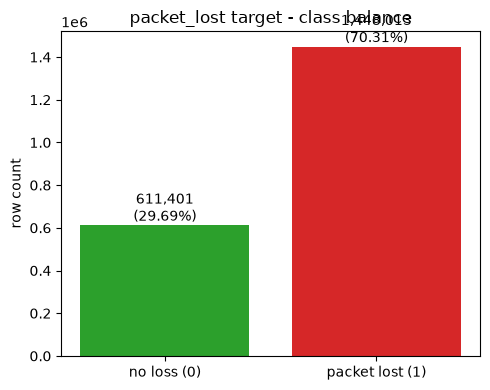

In [13]:
df_final['packet_lost'] = ((df_final['sloss'] + df_final['dloss']) > 0).astype(int)

counts = df_final['packet_lost'].value_counts().reindex([0, 1], fill_value=0)
pct = (counts / len(df_final) * 100).round(2)

plt.figure(figsize=(5, 4))
bars = plt.bar(['no loss (0)', 'packet lost (1)'], counts.values, color=['#2ca02c', '#d62728'])
plt.ylabel('row count')
plt.title('packet_lost target - class balance')
for bar, c, p in zip(bars, counts.values, pct.values):
    plt.text(bar.get_x() + bar.get_width()/2, c, f'{c:,}\n({p}%)', ha='center', va='bottom')
plt.tight_layout()
plt.show()

`total_bytes` / `total_pkts` - simple directional sums of our own outgoing (`s*`) and the destination's (`d*`) traffic. These stay pre-send-safe when only the `s*` half is used later; the totals are kept here mainly to build `avg_pkt_size` and for EDA.

In [14]:
df_final['total_bytes'] = df_final['sbytes'] + df_final['dbytes']
df_final['total_pkts'] = df_final['Spkts'] + df_final['Dpkts']
df_final[['sbytes', 'dbytes', 'total_bytes', 'Spkts', 'Dpkts', 'total_pkts']].head()

,sbytes,dbytes,total_bytes,Spkts,Dpkts,total_pkts
0,132,164,296,2,2,4
1,528,304,832,4,4,8
2,146,178,324,2,2,4
3,132,164,296,2,2,4
4,146,178,324,2,2,4


`avg_pkt_size` = `total_bytes / total_pkts`. There are 0 rows with `total_pkts == 0` here, so no divide-by-zero guard is needed - confirmed below before dividing.

In [15]:
zero_pkt_rows = int((df_final['total_pkts'] == 0).sum())
print(f"Rows with 0 total packets (would cause divide-by-zero): {zero_pkt_rows}")

df_final['avg_pkt_size'] = df_final['total_bytes'] / df_final['total_pkts']
df_final[['total_bytes', 'total_pkts', 'avg_pkt_size']].head()

Rows with 0 total packets (would cause divide-by-zero): 0


,total_bytes,total_pkts,avg_pkt_size
0,296,4,74.0
1,832,8,104.0
2,324,4,81.0
3,296,4,74.0
4,324,4,81.0


`loss_rate` = `(sloss + dloss) / total_pkts` - a continuous "what fraction of packets were lost" signal, richer than the binary `packet_lost` flag alone. Post-send only (built from `sloss`/`dloss`), kept for EDA and later before/after comparisons in the simulation, not as a model input.

In [16]:
df_final['loss_rate'] = (df_final['sloss'] + df_final['dloss']) / df_final['total_pkts']
df_final[['sloss', 'dloss', 'total_pkts', 'loss_rate']].head()

,sloss,dloss,total_pkts,loss_rate
0,0,0,4,0.0
1,0,0,8,0.0
2,0,0,4,0.0
3,0,0,4,0.0
4,0,0,4,0.0


`is_incomplete_conn` - flags connections that didn't end cleanly (`state` not `FIN`/`CON`). Post-send only (the final state is a result, not a precondition), but useful for EDA and for validating that the loss signal makes sense.

is_incomplete_conn
0    1976804
1      82610
Name: count, dtype: int64


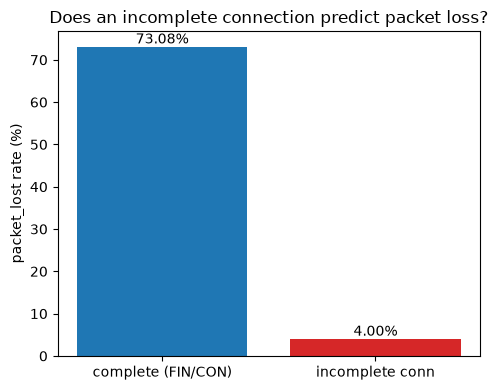

In [17]:
clean_states = {'FIN', 'CON'}
df_final['is_incomplete_conn'] = (~df_final['state'].isin(clean_states)).astype(int)

print(df_final['is_incomplete_conn'].value_counts())

loss_rate_by_state = df_final.groupby('is_incomplete_conn')['packet_lost'].mean() * 100

plt.figure(figsize=(5, 4))
plt.bar(['complete (FIN/CON)', 'incomplete conn'], loss_rate_by_state.values, color=['#1f77b4', '#d62728'])
plt.ylabel('packet_lost rate (%)')
plt.title('Does an incomplete connection predict packet loss?')
for i, v in enumerate(loss_rate_by_state.values):
    plt.text(i, v, f'{v:.2f}%', ha='center', va='bottom')
plt.tight_layout()
plt.show()

`dst_port_bucket` - pre-send-safe replacement for the raw `dsport` column we dropped. Groups the destination port into well-known (0-1023) / registered (1024-49151) / dynamic (49152-65535), plus `invalid` for the corrupted hex entries seen in the raw column.

dsport values that failed numeric conversion (corrupted/hex): 295


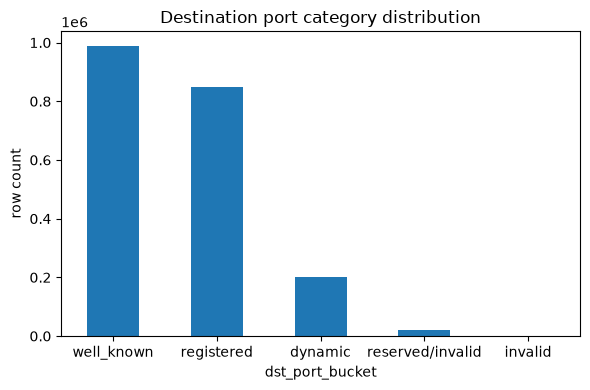

In [18]:
def bucket_port(p):
    if pd.isna(p):
        return 'invalid'
    p = int(p)
    if p == 0:
        return 'reserved/invalid'
    if p <= 1023:
        return 'well_known'
    if p <= 49151:
        return 'registered'
    return 'dynamic'

dsport_numeric = pd.to_numeric(dsport_raw, errors='coerce')
print(f"dsport values that failed numeric conversion (corrupted/hex): {dsport_numeric.isna().sum()}")

df_final['dst_port_bucket'] = dsport_numeric.apply(bucket_port)

order = df_final['dst_port_bucket'].value_counts().index
plt.figure(figsize=(6, 4))
df_final['dst_port_bucket'].value_counts().loc[order].plot(kind='bar', color='#1f77b4')
plt.ylabel('row count')
plt.title('Destination port category distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Section 6 - Sanity-check the finished dataset

A quick check that the engineered features relate to `packet_lost` the way we'd expect, and a reference table marking which columns are safe model inputs (pre-send) vs. label-building/EDA-only (post-send/metadata) for the next notebook.

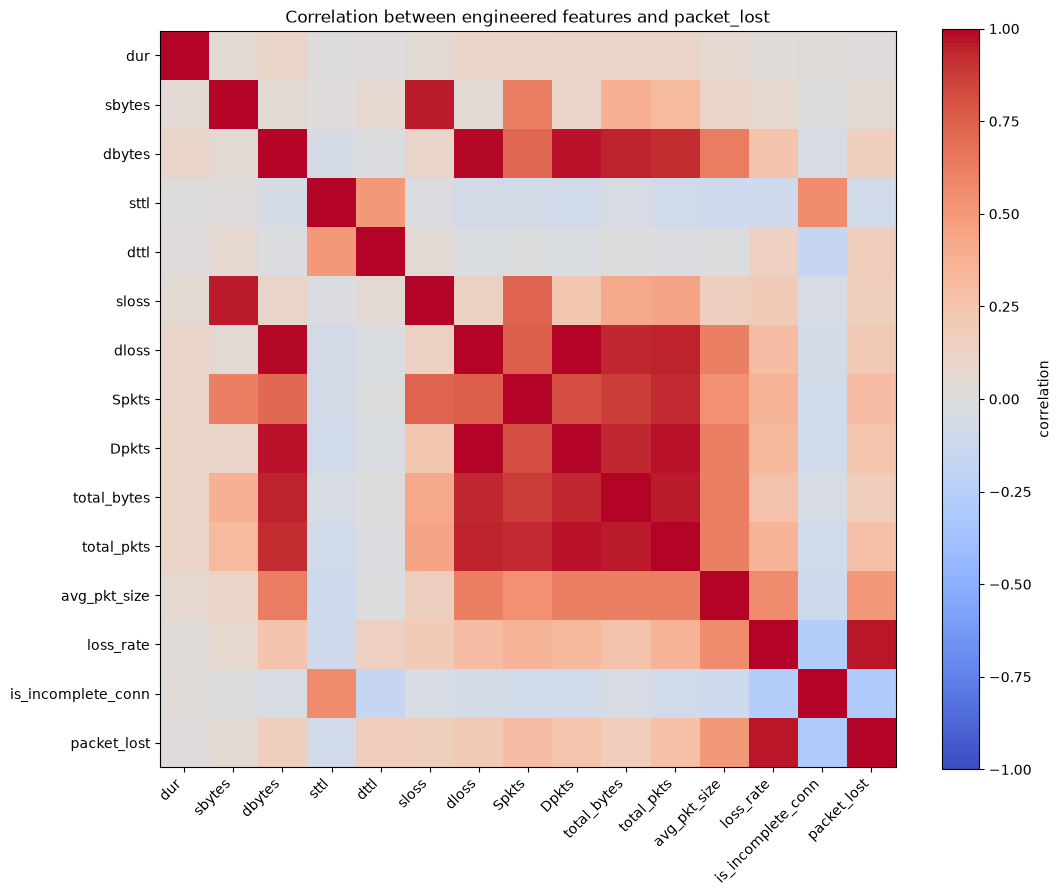

In [19]:
numeric_cols = [
    'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'Spkts', 'Dpkts',
    'total_bytes', 'total_pkts', 'avg_pkt_size', 'loss_rate', 'is_incomplete_conn', 'packet_lost',
]

corr = df_final[numeric_cols].corr()

plt.figure(figsize=(11, 9))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='correlation')
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha='right')
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title('Correlation between engineered features and packet_lost')
plt.tight_layout()
plt.show()

In [20]:
pre_send_candidate_cols = [
    'proto', 'service', 'sbytes', 'Spkts', 'smeansz', 'sttl', 'swin', 'dst_port_bucket',
    'ct_state_ttl', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm',
    'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
]
# This is the BROAD candidate list - every column that is at least theoretically knowable before a
# packet is sent. It is not the final model feature set: some of these (proto, swin, service, Spkts)
# turn out to be statistically unusable once tested properly. That evidence-based narrowing down to
# the final X happens in notebook 03, against X only - none of these columns are dropped from this file.
post_send_or_metadata_cols = [c for c in df_final.columns if c not in pre_send_candidate_cols + ['packet_lost']]

print(f"Pre-send candidates (not yet the final feature set): {len(pre_send_candidate_cols)} columns")
print(f"Post-send / metadata (label-building + EDA only): {len(post_send_or_metadata_cols)} columns")
print(f"Target: packet_lost")
print(f"Total columns in saved file: {df_final.shape[1]}")

Pre-send candidates (not yet the final feature set): 16 columns
Post-send / metadata (label-building + EDA only): 25 columns
Target: packet_lost
Total columns in saved file: 42


In [21]:
df_final.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
proto,2059414,6,tcp,1448858,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,2059414,16,FIN,1433507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dur,2059414.0,NaN,NaN,NaN,0.651027,11.043867,0.0,0.003592,0.026416,0.334151,8786.637695
sbytes,2059414.0,NaN,NaN,NaN,5098.054965,62137.257315,0.0,424.0,1684.0,3728.0,14355774.0
dbytes,2059414.0,NaN,NaN,NaN,41926.203641,169857.501762,0.0,304.0,3080.0,19918.0,14657531.0
sttl,2059414.0,NaN,NaN,NaN,43.595119,50.520898,0.0,31.0,31.0,31.0,255.0
dttl,2059414.0,NaN,NaN,NaN,36.501241,43.703081,0.0,29.0,29.0,29.0,254.0
sloss,2059414.0,NaN,NaN,NaN,6.113913,24.577474,0.0,0.0,4.0,7.0,5319.0
dloss,2059414.0,NaN,NaN,NaN,18.931356,59.526393,0.0,0.0,5.0,15.0,5507.0
service,2059414,13,none,1169177,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Section 7 - Save the final dataset

In [22]:
FINAL_PATH = 'unsw_cleaned_features.csv'
df_final.to_csv(FINAL_PATH, index=False)

print(f"Final cleaned + feature-engineered dataset saved -> {FINAL_PATH}")
print(f"Final shape: {df_final.shape}")

raw_check = pd.read_csv(RAW_PATH, nrows=0)
print(f"Confirmed source file untouched: {RAW_PATH} still has {raw_check.shape[1]} columns")

Final cleaned + feature-engineered dataset saved -> unsw_cleaned_features.csv
Final shape: (2059414, 42)
Confirmed source file untouched: unsw_combined_dataset.csv still has 49 columns


## Recap - what this notebook did, end to end

1. **Loaded** `unsw_combined_dataset.csv` (2,540,047 rows x 49 columns) - never modified.
2. **Basic column decision:** dropped only columns that are objectively unusable regardless of model choice - identity columns, corrupted/random values, near-empty fields. Every column that is *theoretically* a valid pre-send feature (`proto`, `service`, `Spkts`, `swin`, etc.) stays in this file - none of them are judged here.
3. **Step 1 - dropped 14 columns** (raw IPs, ephemeral/corrupted ports, raw timestamps, random TCP sequence numbers, HTTP-only fields, FTP-only fields, a near-constant flag). Kept 35, row count unchanged.
4. **Step 2 - cleaned the data:**
   - Removed exact duplicate rows, using a definition computed on the *full* 49-column record (not the trimmed one) to avoid deleting real scanning/DDoS traffic.
   - Recoded the `service` placeholder `"-"` to `"none"` - a valid category, not missing data.
   - Collapsed 129 rare `proto` values (0.75% of rows) into `"other"`, keeping the 6 protocols with >=1,000 rows as-is.
   - Confirmed the only remaining nulls are `attack_cat`, and only for normal (non-attack) rows, as expected.
5. **Step 3 - engineered 6 new columns:** `packet_lost` (target, derived from `sloss`+`dloss`), `total_bytes`, `total_pkts`, `avg_pkt_size`, `loss_rate`, `is_incomplete_conn`, `dst_port_bucket`.
6. **Saved** the final dataset as `unsw_cleaned_features.csv` (35 base columns + 6 engineered + target = 42 columns).

**Carried forward to the next notebook:** a broad list of 16 "pre-send candidate" columns - notebook 03 tests each one with real statistics and visualizations, and decides which actually belong in `X` (not this file - `X` only).